**Import Libraries**

In [50]:
import pandas as pd
import numpy as np
import joblib

**Load Clean Dataset**

In [51]:
data = pd.read_csv("C:\\Users\\rishi\\IIMSTC-Cohort10-Urban-AQI-Modeler\\data\\clean\\cleaned_air_quality.csv")

In [52]:
data.head()

,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,...,wd_S,wd_SE,wd_SSE,wd_SSW,wd_SW,wd_W,wd_WNW,wd_WSW,month,hour
0,-1.772825,-1.262504,0.088841,-1.258664,-1.076506,0.436428,-1.429120,1.337900,-1.623792,0.0,...,False,False,False,False,False,False,False,False,-1.115861,-1.151424
1,-2.340610,-1.312805,0.191176,-1.222133,-1.076506,0.436428,-1.483582,1.404567,-1.630981,0.0,...,False,False,False,False,False,False,False,False,-1.115861,-1.009477
2,-1.929226,-1.279271,0.805188,-1.002943,-0.906665,0.297851,-1.501735,1.442662,-1.638170,0.0,...,False,False,False,False,False,False,False,False,-1.115861,-0.867530
3,-2.340610,-1.312805,0.805188,-0.491501,-0.736825,-0.071689,-1.538043,1.528376,-1.602226,0.0,...,False,False,False,False,False,False,False,False,-1.115861,-0.725584
4,-2.340610,-1.262504,0.907523,-0.162716,-0.736825,-0.233363,-1.447274,1.614089,-1.602226,0.0,...,False,False,False,False,False,False,False,False,-1.115861,-0.583637


In [53]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301633 entries, 0 to 301632
Data columns (total 39 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   PM2.5                  301633 non-null  float64
 1   PM10                   301633 non-null  float64
 2   SO2                    301633 non-null  float64
 3   NO2                    301633 non-null  float64
 4   CO                     301633 non-null  float64
 5   O3                     301633 non-null  float64
 6   TEMP                   301633 non-null  float64
 7   PRES                   301633 non-null  float64
 8   DEWP                   301633 non-null  float64
 9   RAIN                   301633 non-null  float64
 10  WSPM                   301633 non-null  float64
 11  station_Changping      301633 non-null  bool   
 12  station_Dingling       301633 non-null  bool   
 13  station_Dongsi         301633 non-null  bool   
 14  station_Guanyuan       301633 non-nu

**Define Target & Features**

In [54]:
X = data[[
    'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM',
    'month', 'hour'
]]

y = data['PM2.5']

**Train-Test Split**

In [55]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)


**Evaluation Function**

In [56]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

def evaluate(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"{model_name}")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R2  :", r2)


**Linear Regression**

In [57]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

pred_lr = lr.predict(X_test)

**Random Forest**

In [58]:
from sklearn.ensemble import RandomForestRegressor
'''rf = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)
'''
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

**XGBoost**

In [59]:
import sys
!{sys.executable} -m pip install xgboost

In [60]:
from xgboost import XGBRegressor
xgb = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

**Model comparison**

In [61]:
evaluate(y_test, pred_lr, "Linear Regression")


Linear Regression
RMSE: 0.4793006800215174
MAE : 0.3690404496380132
R2  : 0.7707848397508057


In [62]:
evaluate(y_test, pred_rf, "Random Forest")


Random Forest
RMSE: 0.3726548191105279
MAE : 0.26485550715570594
R2  : 0.8614390884613997


In [63]:
evaluate(y_test, pred_xgb, "XGBoost")

XGBoost
RMSE: 0.34143133286190314
MAE : 0.2366756579914055
R2  : 0.8836854633515394


**Feature Importance**

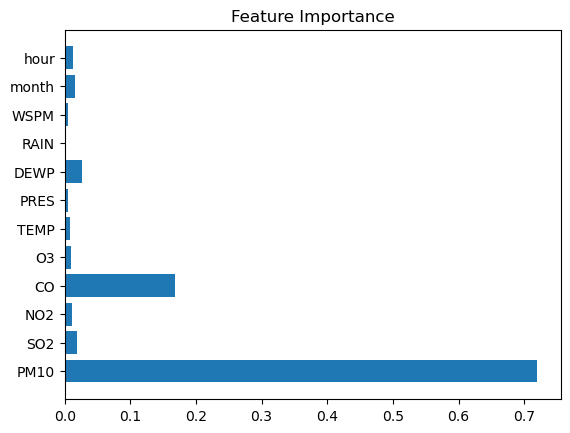

In [64]:
import matplotlib.pyplot as plt

importances = xgb.feature_importances_
features = X.columns

plt.barh(features, importances)
plt.title("Feature Importance")
plt.show()

**Save Models**

In [65]:
import joblib
joblib.dump(xgb, "../models/pm25_xgb_model.pkl")

['../models/pm25_xgb_model.pkl']

In [66]:
joblib.dump(rf, "../models/pm25_rf_model.pkl")

['../models/pm25_rf_model.pkl']